# <font color=#0099CC>**GESTIÓN DE RIESGOS**</font>

### **Fecha: 15/02/2026 | Autores: Javier Fernández Guerra**

## <font color=#0099CC>**0. INTRODUCCIÓN**</font>


En este documento se construye un motor de stress testing con cambios de régimen para un universo multiactivo americano. El objetivo es identificar estados de calma/crisis, cuantificar el riesgo de cola y simular escenarios de estrés económicamente coherentes. El enfoque es interpretable, usando HMM, cópulas y Monte Carlo, sin modelos opacos.

In [1]:
# Importar librerías
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from scipy import stats
from scipy.stats import norm

In [2]:
# CONFIGURACIÓN DE CARGA DE DATOS

# False: cargar datos_mercado.csv y datos_cartera.csv (2006-01-01 a 2026-02-15)
# True: descargar datos actualizados de Yahoo Finance
DESCARGAR_YAHOO_MERCADO = False
DESCARGAR_YAHOO_CARTERA = False

## <font color=#0099CC>**1. SECCIÓN I: DETECCIÓN DE ESTADOS DE MERCADO CON HMM**</font>
### <font color=#336699>**1.1. Descarga de Datos**</font>

Se descargan datos diarios desde 2006 con `yfinance` para representar el pulso del mercado USA:
- **S&P 500** como proxy de mercado.
- **VIX** como medida de estrés/aversión al riesgo.
- **Treasury 2Y/10Y** para condiciones de tipos y pendiente de curva.
- **DXY** y **Oro (GLD)** para dimensiones de refugio/liquidez global.
- **Oil (CL=F)** como termómetro macro/cíclico.


#### 1.1.1. Descarga de Datos

In [3]:
# Definir tickers
tickers = {
    'SP500': '^GSPC',
    'VIX': '^VIX',
    'Treasury_10Y': '^TNX', # Yield del 10Y
    'Treasury_2Y': '^IRX',  # Yield del 2Y
    'GLD': 'GLD',           # Oro
    'DXY': 'DX-Y.NYB',      # Dólar
    'OIL': 'CL=F'           # Petróleo
}

# Cargar datos según configuración
if DESCARGAR_YAHOO_MERCADO:
    try:
        data_raw = yf.download(list(tickers.values()), start='2006-01-01', auto_adjust=True, threads=False)['Close']
        rename_dict = {v: k for k, v in tickers.items()}
        data_raw = data_raw.rename(columns=rename_dict)
    except Exception as e:
        print(f"yfinance falló ({e}). Leyendo datos_mercado.csv")
        data_raw = pd.read_csv('datos_mercado.csv', index_col=0, parse_dates=True)
else:
    data_raw = pd.read_csv('datos_mercado.csv', index_col=0, parse_dates=True)

# Quitamos NaNs
data_raw = data_raw.dropna()

# Mostrar resultados
data_raw

,OIL,DXY,GLD,SP500,Treasury_2Y,Treasury_10Y,VIX
Date,,,,,,,
2006-01-03,63.139999,89.839996,53.119999,1268.800049,4.020,4.370,11.140000
2006-01-04,63.419998,89.139999,53.299999,1273.459961,4.082,4.356,11.370000
2006-01-05,62.790001,89.330002,52.340000,1273.479980,4.090,4.356,11.310000
2006-01-06,64.209999,88.849998,53.720001,1285.449951,4.107,4.379,11.000000
2006-01-09,63.500000,89.250000,54.599998,1290.150024,4.117,4.379,11.130000
...,...,...,...,...,...,...,...
2026-02-09,64.360001,96.820000,467.029999,6964.819824,3.593,4.198,17.360001
2026-02-10,63.959999,96.800003,462.399994,6941.810059,3.590,4.147,17.790001
2026-02-11,64.629997,96.830002,467.630005,6941.470215,3.600,4.172,17.650000


> <u>Comentario</u>: Los datos son claros y completos. No hay necesidad de limpieza ni transformaciones.


### <font color=#336699>**1.2. Construcción de los Features para el HMM**</font>

Se construyen variables que capturan crecimiento, estrés y ciclo de tipos:
- Retornos logarítmicos para precios (S&P, GLD, DXY) para estabilidad y simetría.
- Oil en retorno simple: en abril 2020 los precios negativos rompen el log‑retorno.
- VIX en niveles (miedo absoluto).
- Pendiente de curva (10Y‑2Y) y cambio diario del 10Y para capturar shocks de tipos.

Explicación del Oil en retorno simple:
- En abril 2020, la demanda colapsó y los tanques de almacenamiento estaban saturados.
- Los futuros de WTI llegaron a precio negativo por presiones de entrega física.
- El log‑retorno no es válido con precios ≤ 0.

In [4]:
# ¿Hay datos negativos que interfieran con los retornos logarítmicos?
datos_negativos = pd.DataFrame(data_raw[(data_raw['OIL'] <= 0)]['OIL'])
datos_negativos

,OIL
Date,
2020-04-20,-37.630001


#### 1.2.1. Construcción de los Features

In [5]:
# CONTRUIR FEATURES
features = pd.DataFrame(index=data_raw.index)

# A) RETORNOS LOGARÍTMICOS (para precios)
features['sp500_ret'] = np.log(data_raw['SP500'] / data_raw['SP500'].shift(1))
features['gld_ret'] = np.log(data_raw['GLD'] / data_raw['GLD'].shift(1))
features['oil_ret'] = (data_raw['OIL'] / data_raw['OIL'].shift(1))-1          # Retorno Simple: 2020-04-20 precio negativo
features['dxy_ret'] = np.log(data_raw['DXY'] / data_raw['DXY'].shift(1))

# B) VIX en NIVEL (el miedo absoluto importa)
features['vix_level'] = data_raw['VIX']

# C) YIELD CURVE SLOPE (diferencia de yields)
features['yield_slope'] = data_raw['Treasury_10Y'] - data_raw['Treasury_2Y']

# D) CAMBIO EN YIELD 10Y (first difference)
features['yield_10y_change'] = data_raw['Treasury_10Y'].diff()

# Eliminar NaNs
features = features.dropna()
features.head()

,sp500_ret,gld_ret,oil_ret,dxy_ret,vix_level,yield_slope,yield_10y_change
Date,,,,,,,
2006-01-04,0.003666,0.003383,0.004435,-0.007822,11.37,0.274,-0.014
2006-01-05,0.000016,-0.018175,-0.009934,0.002129,11.31,0.266,0.000
2006-01-06,0.009356,0.026024,0.022615,-0.005388,11.00,0.272,0.023
2006-01-09,0.003650,0.016248,-0.011057,0.004492,11.13,0.262,0.000
2006-01-10,-0.000357,-0.009939,-0.002047,0.000896,10.86,0.251,0.049


### <font color=#336699>**1.3. Hidden Markov Models**</font>

Un HMM asume que el mercado evoluciona entre **estados no observables** (calma/crisis) y que las variables observadas dependen de ese estado. Es útil porque permite **detectar cambios de régimen** de forma interpretable, algo clave para riesgo de cola y pérdida de diversificación. En este notebook lo usamos para clasificar cada día y alimentar la simulación por regímenes.

#### 1.3.1. Entreno de HMM e Inferencia de Estados Ocultos

Estandarizamos las variables para evitar sesgos por escala y estimamos un HMM Gaussiano de 2 estados; después inferimos la secuencia de regímenes diarios.

In [6]:
# Estandarizar variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Inicializar y entrenar HMM
n_states = 2  # por ejemplo, 2: calma / pánico
model = GaussianHMM(
    n_components=n_states,
    covariance_type="full",
    n_iter=1000,
    random_state=42,
    verbose=False
)

# Baum-Welch se ejecuta internamente al llamar a fit()
model.fit(X_scaled)

# Inferir estados ocultos
hidden_states = model.predict(X_scaled)
data_raw = data_raw.copy()          # evitar slices que no permitan agregar columnas
data_raw.loc[features.index, 'REGIME'] = hidden_states

#### 1.3.2. Resultados: Parámetros Optimizados y Estados Ocultos

Se revisan medias, covarianzas, matriz de transición y secuencia de estados para interpretar los regímenes obtenidos.

In [7]:
# PARÁMETROS OPTIMIZADOS
n_states = model.n_components
feature_names = features.columns  # excluyendo "REGIME"

# Medias por estado
for i in range(n_states):
    print(f"\nEstado {i} - Media (estandarizada):")
    df_mean = pd.DataFrame(model.means_[i].reshape(1, -1), columns=feature_names)
    display(df_mean.round(3))

# Covarianzas por estado
for i in range(n_states):
    print(f"\nEstado {i} - Covarianza:")
    df_cov = pd.DataFrame(model.covars_[i], index=feature_names, columns=feature_names)
    display(df_cov.round(3))

# Matriz de transición
print("\nMatriz de transición:")
display(pd.DataFrame(model.transmat_.round(5)))

# Probabilidades iniciales
print("\nProbabilidades iniciales:")
display(pd.DataFrame(model.startprob_.round(5), index=[f"Estado {i}" for i in range(n_states)]))

# DataFrame CON ESTADOS OCULTOS
print("\nDataFrame con regímenes")
display(data_raw.dropna().head())



Estado 0 - Media (estandarizada):


,sp500_ret,gld_ret,oil_ret,dxy_ret,vix_level,yield_slope,yield_10y_change
0,-0.169,-0.077,-0.097,0.049,1.667,0.411,-0.076



Estado 1 - Media (estandarizada):


,sp500_ret,gld_ret,oil_ret,dxy_ret,vix_level,yield_slope,yield_10y_change
0,0.032,0.015,0.019,-0.009,-0.317,-0.078,0.014



Estado 0 - Covarianza:


...

,0,1
0,0.90461,0.09539
1,0.01814,0.98186



Probabilidades iniciales:


,0
Estado 0,0.0
Estado 1,1.0



DataFrame con regímenes


,OIL,DXY,GLD,SP500,Treasury_2Y,Treasury_10Y,VIX,REGIME
Date,,,,,,,,
2006-01-04,63.419998,89.139999,53.299999,1273.459961,4.082,4.356,11.37,1.0
2006-01-05,62.790001,89.330002,52.340000,1273.479980,4.090,4.356,11.31,1.0
2006-01-06,64.209999,88.849998,53.720001,1285.449951,4.107,4.379,11.00,1.0
2006-01-09,63.500000,89.250000,54.599998,1290.150024,4.117,4.379,11.13,1.0
2006-01-10,63.369999,89.330002,54.060001,1289.689941,4.177,4.428,10.86,1.0


> <u>Comentario</u>: el HMM separa estados con medias y covarianzas claramente distintas. En el régimen de crisis aparecen señales de aversión al riesgo (VIX más alto, retornos de equity más débiles y mayor dispersión), lo que valida la interpretación económica de los estados.
>
> La matriz de transición muestra bastante estabilidad, con aproximadamente un 90% de probabilidad de permanecer en un periodo de calma y un 98% de probabilidad de mantenerse en un periodo de crisis. Esto es coherente con las observaciones del mercado, donde los periodos de crisis suelen ser más cortos que los periodos de calma, pero acompañados de estallidos de volatilidad y aumento de las correlaciones.

#### 1.3.3. Filtrado por Longitud del Estado

Para reducir el ruido en la clasificación, los episodios de crisis con una duración inferior a 14 días se reclasifican como periodos de calma. Este criterio evita identificar como crisis picos de volatilidad transitorios y mejora la interpretabilidad del análisis, al centrarse en episodios de tensión sostenida.

La decisión responde a la naturaleza binaria del ejercicio. Incluir estos eventos breves como crisis dificultaría la interpretación macroeconómica, especialmente en variables más estables como la curva de tipos.

In [8]:
# Definir función de filtrado
def filtrar_crisis_cortas(estados, crisis_state, min_dias_crisis=21):
    """Convierte a calma las rachas de crisis con menos de min_dias_crisis días."""
    estados = np.asarray(estados)
    resultado = estados.copy()
    i = 0
    while i < len(estados):
        if estados[i] == crisis_state:
            j = i
            while j < len(estados) and estados[j] == crisis_state:
                j += 1
            if (j - i) < min_dias_crisis:
                resultado[i:j] = 1 - crisis_state
            i = j
        else:
            i += 1
    return resultado

# Identificar crisis por VIX medio más alto para asignar estados correctamente
temp_states = pd.Series(hidden_states, index=features.index)
vix_by_state = features['vix_level'].groupby(temp_states).mean()
crisis_state = int(vix_by_state.idxmax())

# Filtrar crisis
min_dias = 10   # crisis de menos de 2 semanas -> calma
hidden_states = filtrar_crisis_cortas(hidden_states, crisis_state, min_dias)

# Re-etiquetar: 0=calma, 1=crisis
if crisis_state == 0:
    hidden_states = 1 - hidden_states

# Matriz de transición empírica consistente con la re-etiqueta
states = hidden_states.astype(int)
transmat_emp = np.zeros((2, 2), dtype=float)
for i in range(1, len(states)):
    transmat_emp[states[i - 1], states[i]] += 1
transmat_emp = transmat_emp / transmat_emp.sum(axis=1, keepdims=True)

# Probabilidades iniciales empíricas
start_prob_emp = np.array([
    np.mean(states == 0),
    np.mean(states == 1)
])

# Guardar en el DataFrame
data_raw.loc[features.index, 'REGIME'] = hidden_states

#### 1.3.4. Estadísticas por Régimen

Resumen cuantitativo de retornos, volatilidad, VIX y pendiente de curva por estado.

In [9]:
# ESTADÍSTICAS POR RÉGIMEN
print("\n" + "="*60)
print("ESTADÍSTICAS POR RÉGIMEN")
print("="*60)

# Etiquetas fijas tras re-etiquetado
calm_state = 0
crisis_state = 1

for state in [calm_state, crisis_state]:
    state_name = "CALMA" if state == calm_state else "CRISIS"
    mask = hidden_states == state

    print(f"\n{state_name} (Estado {state}):")
    print(f"   - Días: {mask.sum()} ({100*mask.sum()/len(mask):.1f}%)")
    print(f"   - Retorno S&P medio: {features.loc[mask, 'sp500_ret'].mean()*252:.2%} anualizado")
    print(f"   - Volatilidad S&P: {features.loc[mask, 'sp500_ret'].std()*np.sqrt(252):.2%} anualizada")
    print(f"   - VIX promedio: {features.loc[mask, 'vix_level'].mean():.1f}")
    print(f"   - Yield Slope promedio: {features.loc[mask, 'yield_slope'].mean():.2f}%")

# MATRIZ DE TRANSICIÓN
print("\n" + "="*60)
print("MATRIZ DE TRANSICIÓN")
print("="*60)
trans_df = pd.DataFrame(
    transmat_emp,
    index=[f'De Calma ({calm_state})', f'De Crisis ({crisis_state})'],
    columns=[f'A Calma ({calm_state})', f'A Crisis ({crisis_state})']
)
print(trans_df.round(4))

# Calcular duraciones esperadas
# Nota: se reportan por estado re-etiquetado
dur_calm = 1 / (1 - transmat_emp[calm_state, calm_state])
dur_crisis = 1 / (1 - transmat_emp[crisis_state, crisis_state])
print(f"\nDuración media en Calma: {dur_calm:.1f} días")
print(f"Duración media en Crisis: {dur_crisis:.1f} días")
print("\n" + "="*60)


ESTADÍSTICAS POR RÉGIMEN

CALMA (Estado 0):
   - Días: 4420 (87.5%)
   - Retorno S&P medio: 13.57% anualizado
   - Volatilidad S&P: 13.59% anualizada
   - VIX promedio: 17.0
   - Yield Slope promedio: 1.19%

CRISIS (Estado 1):
   - Días: 634 (12.5%)
   - Retorno S&P medio: -27.68% anualizado
   - Volatilidad S&P: 41.71% anualizada
   - VIX promedio: 36.3
   - Yield Slope promedio: 1.89%

MATRIZ DE TRANSICIÓN
               A Calma (0)  A Crisis (1)
De Calma (0)        0.9968        0.0032
De Crisis (1)       0.0221        0.9779

Duración media en Calma: 315.6 días
Duración media en Crisis: 45.3 días



> <u>Comentario</u>:
>
> - <u>Estadísticas por régimen</u>: en el régimen de calma se observan retornos más estables, menor volatilidad y un entorno de riesgo contenido. En crisis, los retornos son más erráticos, la volatilidad y el VIX aumentan y el riesgo de cola se intensifica.
>
>- <u>Matriz de transición</u>: tras el filtrado por longitud del estado —descartando crisis de menos de 14 días— la matriz adquiere mayor estabilidad y se concentra en la diagonal, reflejando la persistencia de los regímenes. En particular, la probabilidad de permanecer en calma aumenta del 98% al 99,7%. Este ajuste implica una cierta infraestimación de episodios negativos de alta volatilidad, a cambio de una mayor interpretabilidad en la identificación de crisis estructurales o sistémicas.
>
>Como consecuencia, episodios de estrés transitorios, como el asociado al miedo a una guerra comercial en el cuarto trimestre de 2018, no se identifican como crisis. El modelo resulta así más lento en reaccionar a picos de volatilidad, pero evita salidas prematuras del mercado ante shocks de corta duración.

#### 1.3.5. Gráfico de Estados Ocultos

Visualización del S&P 500 con el régimen detectado y eventos históricos relevantes.

Gráfico de Estados Ocultos:


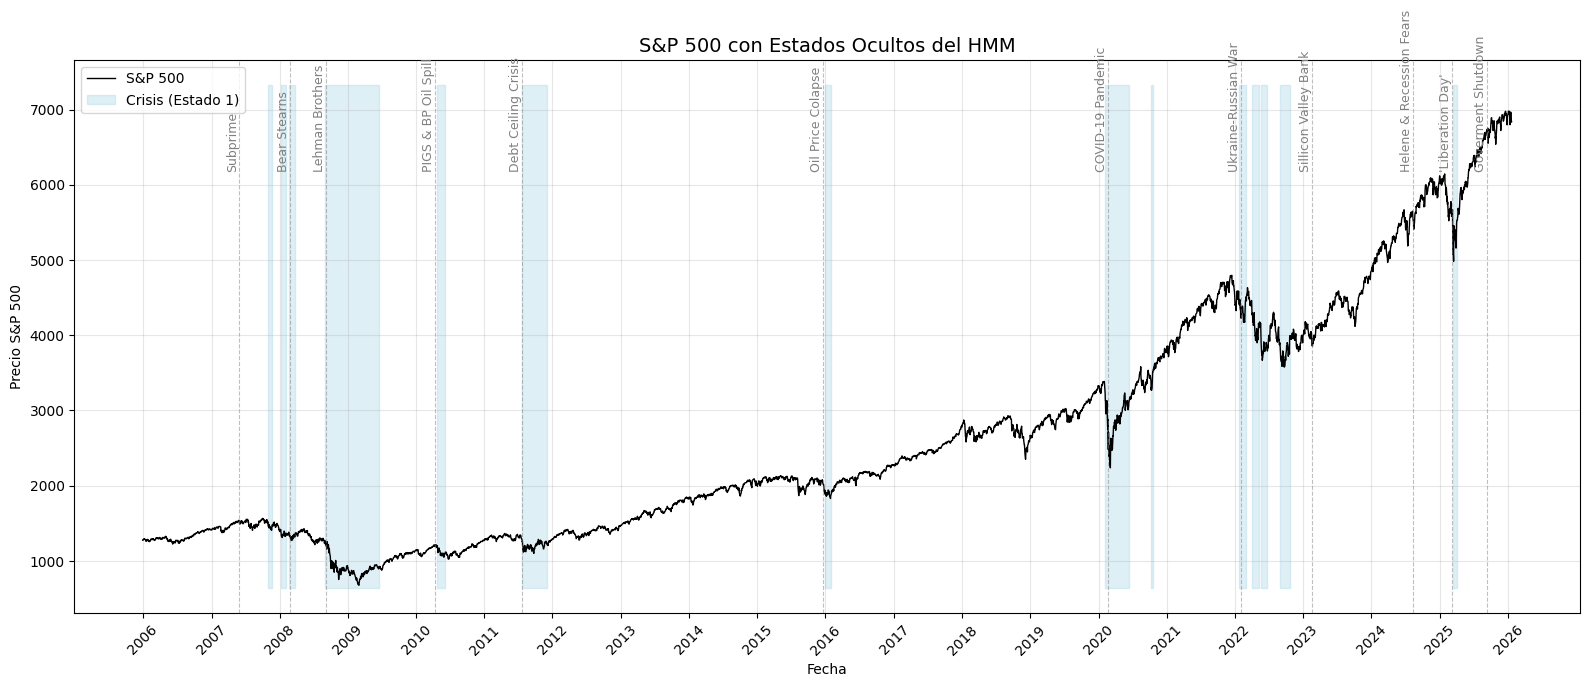

In [10]:
# GRAFICAR RESULTADO
# Crear DataFrame con estados
df_plot = pd.DataFrame({
    'SP500': data_raw.loc[features.index, 'SP500'],
    'REGIME': hidden_states
})

# Etiquetas fijas tras re-etiquetado
crisis_state = 1

plt.figure(figsize=(16, 7))
plt.plot(df_plot.index, df_plot['SP500'], color='black', linewidth=1, label='S&P 500', zorder=2)

# Colorear fondo: blanco=calma, azul=crisis
crisis_mask = df_plot['REGIME'] == crisis_state
plt.fill_between(df_plot.index, 
                 df_plot['SP500'].min() * 0.95, 
                 df_plot['SP500'].max() * 1.05,
                 where=crisis_mask, 
                 color='lightblue', 
                 alpha=0.4, 
                 label='Crisis (Estado 1)')

# Marcar eventos conocidos
crisis_events = {
    '2007-06-04': 'Subprime', # Primeros efectos de la crisis subpprime
    '2008-03-03': 'Bear Stearns', # Quiebra el fondo de inversión Bear Stearns, nerviosismo en el mercado
    '2008-09-15': 'Lehman Brothers', # Quiebra Lehman Brothers
    '2010-04-20': 'PIGS & BP Oil Spill', # PIGS & Petrolero se hunde en el Golfo de México
    '2011-08-01': 'Debt Ceiling Crisis', # Bono Americano deja de ser AAA
    '2016-01-04': 'Oil Price Colapse',  # Precio del barril cae a 30$/barril & se ralentiza el crecimiento global (ej.: China)
    '2020-03-11': 'COVID-19 Pandemic',  # OMS declara Pandemia Mundial
    '2022-02-24': 'Ukraine-Russian War',  # Rusia invade Ucrania
    '2023-03-10': 'Sillicon Valley Bank', # Quiebra el Sillicon Valley Bank
    '2024-09-03': 'Helene & Recession Fears', # Huracán Helene & temores de recesión
    '2025-04-02': "'Liberation Day'", # Trump impone arenceles del 10% en todas las importaciones a USA
    '2025-10-03': 'Goverment Shutdown' #Cierre parcial del Gobierno más largo de la historia de USA
}

for date, label in crisis_events.items():
    if pd.to_datetime(date) in df_plot.index:
        plt.axvline(pd.to_datetime(date), color='grey', linestyle='--', alpha=0.5, linewidth=0.8)
        plt.text(pd.to_datetime(date), df_plot['SP500'].max() * 0.89, label, 
                rotation=90, fontsize=9, ha='right', color='grey')

# Número de fechas en el eje X
step = max(1, len(df_plot.index)//20)
ticks = df_plot.index[::step]
plt.xticks(ticks, [d.year for d in ticks], rotation=45)

plt.title('S&P 500 con Estados Ocultos del HMM', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Precio S&P 500')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
print('Gráfico de Estados Ocultos:')
plt.show()

> <u>Comentario</u>: los bloques azules de crisis percibidos por el HMM coinciden con eventos históricos (2008, 2020, 2022, etc.). Esto sugiere que el modelo captura cambios de régimen con sentido económico, descartando las correcciones de menor calado.

### <font color=#336699>**1.4. Análisis Marginal**</font>

#### 1.4.1. Media, Volatilidad, Skewness y Curtosis por Estado

Se calculan los momentos condicionales para comparar el perfil de riesgo entre estados.

In [11]:
# Estadísticas marginales condicionales por estado (sin anualizar)
state_series = pd.Series(hidden_states, index=features.index, name="REGIME")
features_with_state = features.copy()
features_with_state["REGIME"] = state_series

stats = []
for state in sorted(features_with_state["REGIME"].dropna().unique()):
    data_state = features_with_state[features_with_state["REGIME"] == state].drop(columns=["REGIME"])
    summary = pd.DataFrame({
        "mean": data_state.mean(),
        "volatility": data_state.std(),
        "skewness": data_state.skew(),
        "kurtosis": data_state.kurt()
    })
    summary.index.name = "variable"
    summary["state"] = state
    stats.append(summary.reset_index().set_index(["state", "variable"]))

stats_df = pd.concat(stats).sort_index()
print("\nEstadísticas condicionales por estado (media, volatilidad, skewness, kurtosis):")
display(stats_df.round(4))


Estadísticas condicionales por estado (media, volatilidad, skewness, kurtosis):


mean  volatility  skewness  kurtosis
state variable                                                 
0     dxy_ret           -0.0000      0.0042    0.0275    1.1619
      gld_ret            0.0004      0.0104   -0.7831    7.0878
      oil_ret            0.0004      0.0201   -0.0715    2.5017
      sp500_ret          0.0005      0.0086   -0.4217    2.1477
      vix_level         17.0401      4.5979    0.7729    0.3396
      yield_10y_change   0.0005      0.0501    0.0908    0.8905
      yield_slope        1.1867      1.2621   -0.0904   -0.7475
1     dxy_ret            0.0001      0.0075   -0.1944    0.7260
      gld_ret            0.0004      0.0175    0.1060    3.3680
      oil_ret           -0.0060      0.1414  -17.0074  353.9407
      sp500_ret         -0.0011      0.0263   -0.1412    2.6401
      vix_level         36.2985     11.5792    1.5324    2.1730
      yield_10y_change  -0.0038      0.0915   -0.1539    1.4085
      yield_slope        1.8861      1.0170   -0.1990   -0.9405

> <u>Comentario</u>:
> En el régimen de crisis, los retornos de renta variable disminuyen mientras aumentan los de renta fija (caída de yields). La volatilidad y la kurtosis se incrementan, reflejando colas más gruesas, y la asimetría se vuelve más negativa en los activos de riesgo.
>
> Esto confirma que el régimen de crisis concentra riesgo de cola, penaliza a los activos de riesgo y beneficia a los activos refugio. El oro, por su parte, mantiene una rentabilidad similar, lo que sugiere que actúa más como un activo descorrelacionador que como refugio clásico.

#### 1.4.2. Visualización de Distribuciones por Estado

Histogramas por régimen para observar colas, asimetría y dispersión. **Recordatorio**: Estado 0 = Calma, Estado 1 = Crisis.

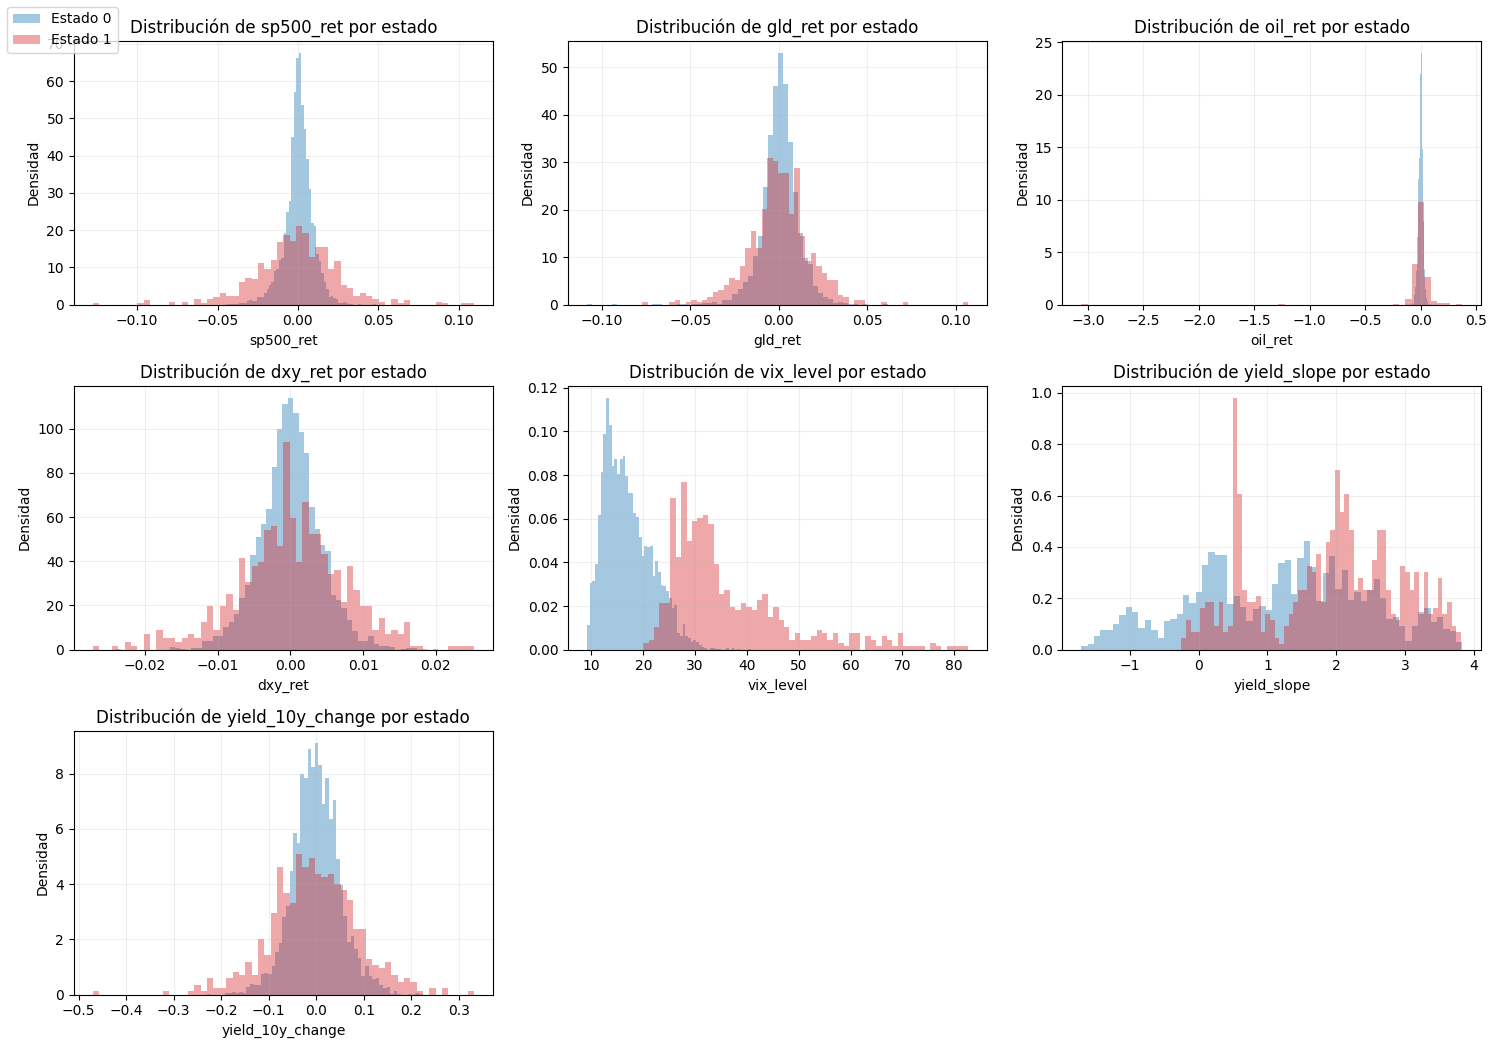

In [12]:
# Distribuciones por estado en un panel
states = sorted(features_with_state["REGIME"].dropna().unique())
colors = {0: "#1f77b4", 1: "#d62728"}

cols = list(features.columns)
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, col in enumerate(cols):
    ax = axes[idx]
    for state in states:
        data_state = features_with_state.loc[features_with_state["REGIME"] == state, col]
        ax.hist(
            data_state,
            bins=60,
            density=True,
            alpha=0.4,
            color=colors.get(state, None),
            label=f"Estado {state}"
        )
    ax.set_title(f"Distribución de {col} por estado")
    ax.set_xlabel(col)
    ax.set_ylabel("Densidad")
    ax.grid(alpha=0.2)

# Ocultar ejes vacíos
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

# Leyenda única
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left")

plt.tight_layout()
plt.show()

> <u>Comentario</u>: en el régimen de crisis, las distribuciones se ensanchan y presentan colas más pesadas; en calma, son más concentradas. La evidencia visual refuerza claramente la separación entre regímenes. El VIX destaca de nuevo como el indicador con la señal más nítida, mostrando distribuciones prácticamente sin solapamiento entre ambos regímenes.

### <font color=#336699>**1.5. Correlaciones y Cópulas por Estado**</font>

#### 1.5.1. Correlaciones

Se comparan matrices de Pearson en calma vs estrés para medir pérdida de diversificación.

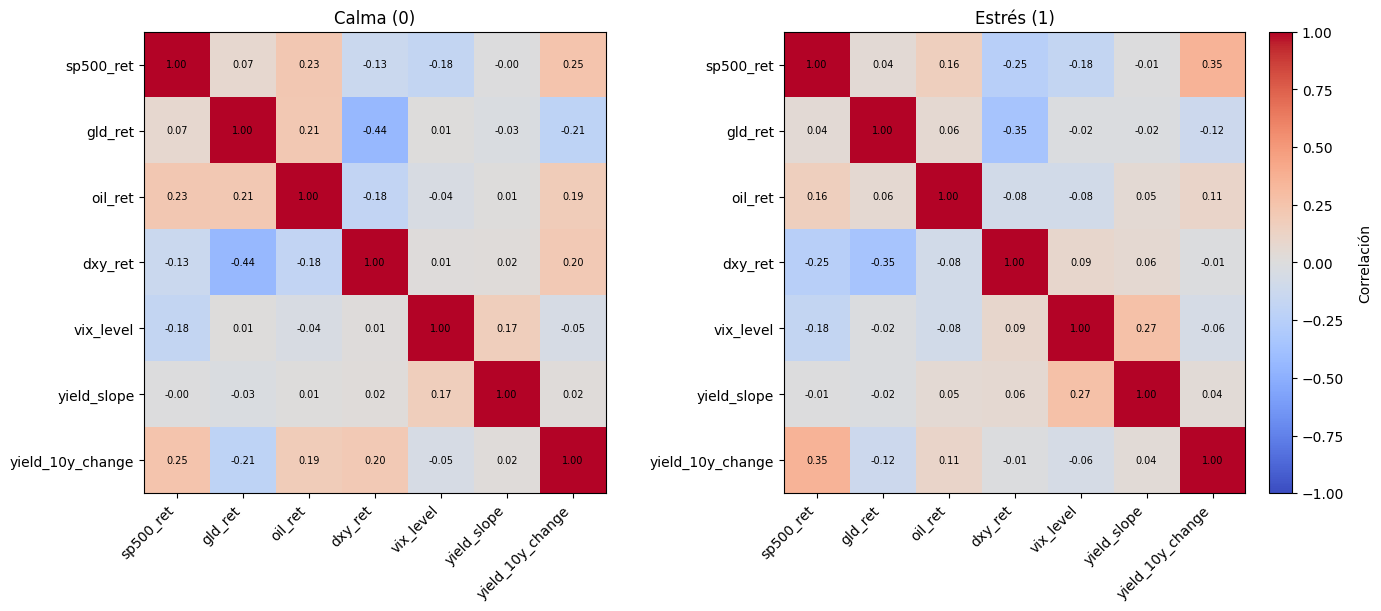

In [13]:
# Matriz de correlación de Pearson por estado y ajuste de cópula Gaussiana
from sklearn.preprocessing import QuantileTransformer

# Variables a incluir en las correlaciones/copulas
cols = list(features.columns)

# Pearson por estado
corr_calm = features_with_state.loc[features_with_state["REGIME"] == 0, cols].corr(method="pearson")
corr_stress = features_with_state.loc[features_with_state["REGIME"] == 1, cols].corr(method="pearson")

# Heatmaps (lado a lado)

def plot_corr_heatmap(ax, corr, title):
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm")

    ax.set_xticks(np.arange(len(corr.columns)))
    ax.set_yticks(np.arange(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr.index)

    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", color="black", fontsize=7)

    ax.set_title(title)
    return im

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
im1 = plot_corr_heatmap(axes[0], corr_calm, "Calma (0)")
plot_corr_heatmap(axes[1], corr_stress, "Estrés (1)")

# Barra de color compartida fuera de los subplots
cbar = fig.colorbar(im1, ax=axes, location="right", fraction=0.046, pad=0.02)
cbar.ax.set_ylabel("Correlación", rotation=90, labelpad=10)
plt.show()

> <u>Comentario</u>: se observa cómo las correlaciones (la mayoría) aumentan en estrés, especialmente entre activos de riesgo. Esto es consistente con la pérdida de diversificación cuando el mercado entra en crisis.
>

> 

#### 1.5.2. Cópulas por Estado

Se ajustan cópulas para capturar dependencia en colas, especialmente en crisis.

In [14]:
# Ajuste de cópula Gaussiana (aprox. con transformada a normal)
def fit_gaussian_copula_corr(X):
    n_q = min(1000, len(X))
    qt = QuantileTransformer(output_distribution="normal", n_quantiles=n_q, random_state=42)
    Xn = qt.fit_transform(X)
    return pd.DataFrame(np.corrcoef(Xn, rowvar=False), index=cols, columns=cols)

# Calma
X_calm = features_with_state.loc[features_with_state["REGIME"] == 0, cols].dropna()
cor_gauss_calm = fit_gaussian_copula_corr(X_calm)

# Estrés
X_stress = features_with_state.loc[features_with_state["REGIME"] == 1, cols].dropna()
cor_gauss_stress = fit_gaussian_copula_corr(X_stress)

print("Parámetros de la cópula Gaussiana (matriz de correlación) - Calma (0)")
display(cor_gauss_calm.round(3))

print("Parámetros de la cópula Gaussiana (matriz de correlación) - Estrés (1)")
display(cor_gauss_stress.round(3))

Parámetros de la cópula Gaussiana (matriz de correlación) - Calma (0)


,sp500_ret,gld_ret,oil_ret,dxy_ret,vix_level,yield_slope,yield_10y_change
sp500_ret,1.000,0.074,0.227,-0.132,-0.134,0.004,0.241
gld_ret,0.074,1.000,0.218,-0.468,0.009,-0.024,-0.222
oil_ret,0.227,0.218,1.000,-0.187,-0.040,0.004,0.189
dxy_ret,-0.132,-0.468,-0.187,1.000,0.012,0.015,0.202
vix_level,-0.134,0.009,-0.040,0.012,1.000,0.172,-0.047
yield_slope,0.004,-0.024,0.004,0.015,0.172,1.000,0.029
yield_10y_change,0.241,-0.222,0.189,0.202,-0.047,0.029,1.000


Parámetros de la cópula Gaussiana (matriz de correlación) - Estrés (1)


,sp500_ret,gld_ret,oil_ret,dxy_ret,vix_level,yield_slope,yield_10y_change
sp500_ret,1.000,0.021,0.367,-0.257,-0.180,0.001,0.350
gld_ret,0.021,1.000,0.190,-0.353,-0.007,-0.026,-0.115
oil_ret,0.367,0.190,1.000,-0.215,-0.136,-0.012,0.304
dxy_ret,-0.257,-0.353,-0.215,1.000,0.092,0.073,-0.014
vix_level,-0.180,-0.007,-0.136,0.092,1.000,0.284,-0.052
yield_slope,0.001,-0.026,-0.012,0.073,0.284,1.000,0.059
yield_10y_change,0.350,-0.115,0.304,-0.014,-0.052,0.059,1.000


> <u>Comentario</u>: la cópula en estrés refleja dependencia más fuerte en colas. Esta elección es coherente con episodios en los que movimientos extremos se producen de forma conjunta, y correlaciones aumentan entre activos.

### <font color=#336699>**1.6. Conclusión Sección I**</font>

El HMM separa de forma interpretable un estado de calma y otro de crisis, con diferencias claras en volatilidad, colas y co-movimientos. Las variables utilizadas (S&P 500, VIX, curva de tipos, DXY, oro y petróleo) ofrecen una lectura económica coherente del ciclo, permitiendo identificar episodios de estrés con base cuantitativa y visual.

Se ha optado por incluir activos con baja correlación entre sí para evitar problemas de multicolinearidad y mejorar la interpretabilidad del análisis.

Entre los indicadores utilizados, el VIX destaca como la señal más clara, con distribuciones prácticamente sin solapamiento entre regímenes, lo que lo convierte en el indicador más fiable para la identificación de crisis.

El S&P 500 refuerza esta lectura, actuando como un indicador directo de crisis tanto por sus retornos negativos como por una volatilidad sustancialmente más elevada que en periodos de calma.

Desde una perspectiva macro-financiera, los periodos de crisis coinciden con fases de steepening de la curva de tipos superiores a la media. Aunque la inversión de la curva se interpreta habitualmente como señal de recesión, el análisis sugiere que se trata de una señal muy anticipada. Los episodios de crisis y de retornos negativos en renta variable se concentran en el steepening posterior a la inversión, cuando el endurecimiento de la política monetaria presiona el tramo corto de la curva y los tipos largos caen.

En este contexto, el bono a 10 años actúa generalmente como activo refugio, con retornos positivos derivados de la caída de los yields en la mayoría de las crisis, salvo en episodios dominados por tensiones inflacionarias, como en 2022. Esto sugiere que la mayor parte de las crisis identificadas responden a growth scares más que a shocks inflacionarios.

El petróleo emerge como un indicador adelantado de growth scare. Aunque existen crisis en las que su precio repunta con fuerza, lo más habitual es que los episodios de estrés estén asociados a miedos de recesión o desaceleración, con destrucción de demanda y correcciones en materias primas cíclicas.

Finalmente, el oro presenta un comportamiento más neutral entre regímenes, actuando como un activo descorrelacionador más que como refugio clásico. Dada su baja correlación con el resto de activos, su inclusión no introduce problemas de multicolinearidad, aunque su valor informativo es limitado.

## <font color=#0099CC>**2. SECCIÓN II: SIMULACIONES**</font>
### <font color=#336699>**2.1. Universo de activos y limpieza**</font>

En esta sección construimos el motor de simulación y validamos su realismo.
- Universo: AAPL, AMZN, BAC, BRK-B, CVX, ENPH, GLD, GME, GOOGL, JNJ, JPM, MSFT, NVDA, PG, XOM, HYG, Treasury 10Y y Treasury 2Y.
- Bonos 2Y/10Y: se aproximan usando los yields diarios (^IRX y ^TNX) convertidos a retornos de precio con duración constante.
- High Yield: se usa el ETF `HYG` como proxy del índice BAMLH0A0HYM2.
- Limpieza: se alinean fechas y se eliminan NaN para garantizar series consistentes.
- Reproducibilidad: se fija semilla en las simulaciones.


In [15]:
# CARGA Y PREPARACIÓN DE DATOS MULTIACTIVO
warnings.filterwarnings("ignore")
np.random.seed(42)

# Definir parámetros
start_date = "2006-01-01"
horizon_days = 126  # ~6 meses de trading
n_paths = 10000

portfolio_tickers = [
    "AAPL", "AMZN", "BAC", "BRK-B", "CVX", "ENPH", "GLD", "GME",
    "GOOGL", "JNJ", "JPM", "MSFT", "NVDA", "PG", "XOM", "HYG"
]
yield_tickers = {"US10Y": "^TNX", "US2Y": "^IRX"}

if DESCARGAR_YAHOO_CARTERA:
    prices = yf.download(portfolio_tickers, start=start_date, auto_adjust=True)["Close"]
    yields = yf.download(list(yield_tickers.values()), start=start_date, auto_adjust=True)["Close"]
    yields = yields.rename(columns={v: k for k, v in yield_tickers.items()})
    price_returns = np.log(prices / prices.shift(1))
    yield_decimal = yields / 100.0
    bond_duration = {"US10Y": 8.5, "US2Y": 1.9}
    bond_returns = pd.DataFrame(index=yield_decimal.index)
    for col, dur in bond_duration.items():
        bond_returns[col] = -dur * yield_decimal[col].diff()
    returns_all = pd.concat([price_returns, bond_returns], axis=1)
    returns_all = returns_all[portfolio_tickers + ["US10Y", "US2Y"]]
else:
    returns_all = pd.read_csv('datos_cartera.csv', index_col=0, parse_dates=True)

returns_all.head()

,AAPL,AMZN,BAC,BRK-B,CVX,ENPH,GLD,GME,GOOGL,JNJ,JPM,MSFT,NVDA,PG,XOM,HYG,US10Y,US2Y
Date,,,,,,,,,,,,,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,0.002938,-0.006960,-0.010677,0.000674,-0.002882,NaN,0.003383,0.034675,0.022739,0.015297,-0.005788,0.004832,0.027612,0.001870,0.001709,NaN,0.001190,-0.001178
2006-01-05,-0.007900,0.008430,0.001287,-0.002362,-0.012297,NaN,-0.018175,0.109210,0.013386,-0.004163,0.003024,0.000741,0.022397,-0.003232,-0.004964,NaN,-0.000000,-0.000152
2006-01-06,0.025486,0.004606,-0.001502,0.003373,0.018052,NaN,0.026024,0.031917,0.031456,0.004483,0.007021,-0.002969,0.016293,-0.001022,0.019540,NaN,-0.001955,-0.000323
2006-01-09,-0.003282,-0.016641,0.000644,0.003026,-0.005077,NaN,0.016248,-0.004945,0.002659,0.006210,0.016112,-0.001860,0.027531,0.007475,-0.000504,NaN,-0.000000,-0.000190


> <u>Comentario</u>:  Solo hay dos activos con datos faltantes para determinadas fechas (HYG y ENPH). En próximos apartados se explica cómo se lidia con estos NaNs a la hora de crear la cartera equiponderada y las cópulas. No hay necesidad de limpieza ni transformación.


### <font color=#336699>**2.2. Cartera equiponderada y retorno histórico**</font>

Se alinean los retornos con los regímenes estimados en la Sección I y se contrsuye la cartera equiponderada (sin rebalanceo). Se obtiene el wealth index histórico como referencia de validación.

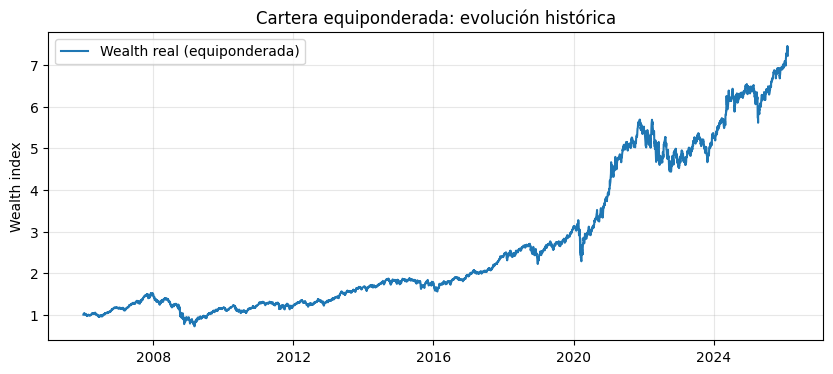

In [16]:
# CARTERA EQUIPONDERADA Y RETORNO HISTÓRICO
state_series = pd.Series(hidden_states, index=features.index, name="REGIME")

# Alinear fechas entre retornos y regímenes
common_idx = returns_all.index.intersection(state_series.index)
returns_all = returns_all.loc[common_idx]
state_series = state_series.loc[common_idx]

# Cartera equiponderada (sin rebalanceo): equiponderación solo con activos disponibles.
# En fechas con NaNs (HYG, ENPH), se promedian solo los activos con datos.
portfolio_returns = returns_all.mean(axis=1, skipna=True).dropna()
wealth_real = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(10, 4))
plt.plot(wealth_real.index, wealth_real, color="#1f77b4", label="Wealth real (equiponderada)")
plt.title("Cartera equiponderada: evolución histórica")
plt.ylabel("Wealth index")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

> **Nota sobre la metodología**
>
> La cartera equiponderada incluye únicamente los activos que están disponibles para la inversión en cada momento. Por ejemplo, HYG se incorpora a la cartera en 2007, mientras que Enphase lo hace tras su IPO en 2012.

### <font color=#336699>**2.3. Anatomía del riesgo (marginales por régimen)**</font>

Se calcula la media, volatilidad, skewness y kurtosis condicionales al régimen para cada activo. Esto conecta el HMM con el riesgo específico de cada instrumento.

In [17]:
# MARGINALES POR RÉGIMEN
def compute_stats(df):
    return pd.DataFrame({
        "mean_daily": df.mean(),
        "vol_daily": df.std(),
        "skew": df.skew(),
        "kurt": df.kurt()
    })

stats_calm = compute_stats(returns_all[state_series == 0])
stats_stress = compute_stats(returns_all[state_series == 1])

stats_calm["mean_annual"] = stats_calm["mean_daily"] * 252
stats_calm["vol_annual"] = stats_calm["vol_daily"] * np.sqrt(252)
stats_stress["mean_annual"] = stats_stress["mean_daily"] * 252
stats_stress["vol_annual"] = stats_stress["vol_daily"] * np.sqrt(252)

print("Estadísticas por régimen (Calma)")
display(stats_calm.round(4))

print("Estadísticas por régimen (Estrés)")
display(stats_stress.round(4))

# Preguntas específicas
hyg_vol_calm = stats_calm.loc["HYG", "vol_annual"]
hyg_vol_stress = stats_stress.loc["HYG", "vol_annual"]

print(f"\nHYG: vol anualizada en Calma = {hyg_vol_calm:.2%}")
print(f"HYG: vol anualizada en Estrés = {hyg_vol_stress:.2%}")
print(f"Incremento relativo = {(hyg_vol_stress / hyg_vol_calm - 1):.1%}")

print("\nGLD: media anualizada y volatilidad por régimen")
print(stats_calm.loc["GLD", ["mean_annual", "vol_annual"]].rename("Calma"))
print(stats_stress.loc["GLD", ["mean_annual", "vol_annual"]].rename("Estrés"))

Estadísticas por régimen (Calma)


,mean_daily,vol_daily,skew,kurt,mean_annual,vol_annual
AAPL,0.0012,0.0172,-0.0861,3.6971,0.2946,0.2734
AMZN,0.0012,0.0210,0.7644,18.3482,0.2906,0.3327
BAC,0.0006,0.0179,0.5404,8.0894,0.1599,0.2845
BRK-B,0.0006,0.0100,-0.0008,2.8831,0.1463,0.1590
CVX,0.0005,0.0134,-0.0833,1.9755,0.1334,0.2133
ENPH,0.0007,0.0488,-0.1370,9.4885,0.1786,0.7752
GLD,0.0004,0.0103,-0.7825,7.1292,0.1070,0.1641
GME,0.0007,0.0514,0.9622,79.3895,0.1846,0.8165
GOOGL,0.0009,0.0165,0.4235,10.0132,0.2207,0.2626
JNJ,0.0005,0.0092,-0.6213,8.5031,0.1244,0.1453


Estadísticas por régimen (Estrés)


,mean_daily,vol_daily,skew,kurt,mean_annual,vol_annual
AAPL,-0.0008,0.0335,-0.1818,3.4183,-0.1940,0.5318
AMZN,-0.0010,0.0374,-0.0100,1.8276,-0.2634,0.5930
BAC,-0.0036,0.0678,-0.1277,4.7338,-0.9169,1.0760
BRK-B,-0.0007,0.0271,0.4824,4.7735,-0.1767,0.4307
CVX,-0.0007,0.0363,-0.4137,8.1338,-0.1727,0.5768
ENPH,-0.0018,0.0660,-0.3435,2.7693,-0.4426,1.0477
GLD,0.0004,0.0175,0.1060,3.3680,0.1060,0.2774
GME,-0.0017,0.0525,0.4433,2.6490,-0.4362,0.8328
GOOGL,-0.0009,0.0301,0.0135,1.8755,-0.2234,0.4776
JNJ,-0.0003,0.0192,0.4557,4.8800,-0.0863,0.3048



HYG: vol anualizada en Calma = 6.46%
HYG: vol anualizada en Estrés = 25.04%
Incremento relativo = 287.8%

GLD: media anualizada y volatilidad por régimen
mean_annual    0.107005
vol_annual     0.164115
Name: Calma, dtype: float64
mean_annual    0.105997
vol_annual     0.277357
Name: Estrés, dtype: float64


> <u>Comentario</u>: 
>
> - <u>Resultados</u>: HYG muestra un aumento notable de volatilidad al pasar a crisis (ver tabla), lo que confirma un deterioro del crédito high yieldque pesa en exceso sobre la caída de los yields de los activos más seguros. GLD mantiene un perfil más defensivo (mejor media y/o menor caída relativa en estrés), aunque suele mostrar mayor volatilidad en episodios extremos.
>
> - <u>Observación clave</u>: las variables que más distinguen el estado de crisis son el repunte del VIX, el aumento de volatilidad en activos de riesgo, colas más gruesas (kurtosis) y correlaciones más altas entre activos. Económicamente, esto refleja una dinámica de aversión al riesgo, venta forzada y pérdida de diversificación.

### <font color=#336699>**2.4. Dependencia multiactivo: correlaciones y cópulas**</font>

Estimamos correlaciones por régimen y preparamos cópulas:
- <u>Calma</u>: cópula gaussiana (dependencia moderada y simétrica).
- <u>Estrés</u>: t‑cópula (captura dependencia en colas y co‑movimientos extremos).
- <u>df de la t‑cópula</u>: se fija en un valor bajo (p. ej., 4) para reforzar colas; puede calibrarse con datos históricos.

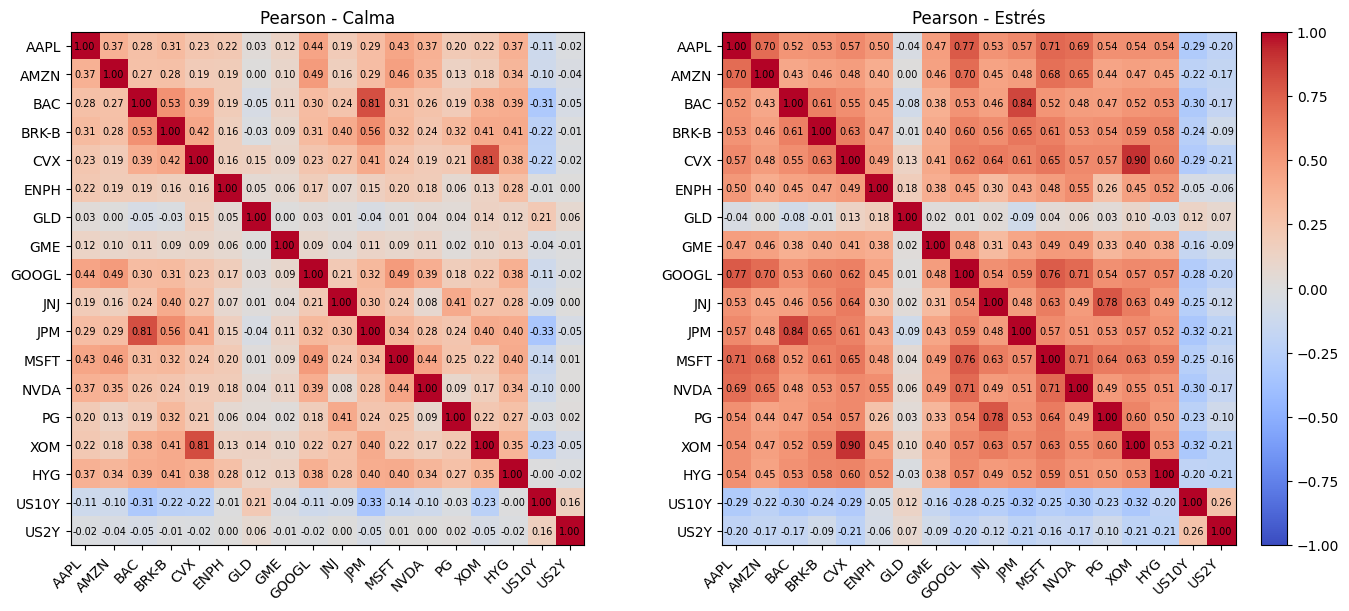

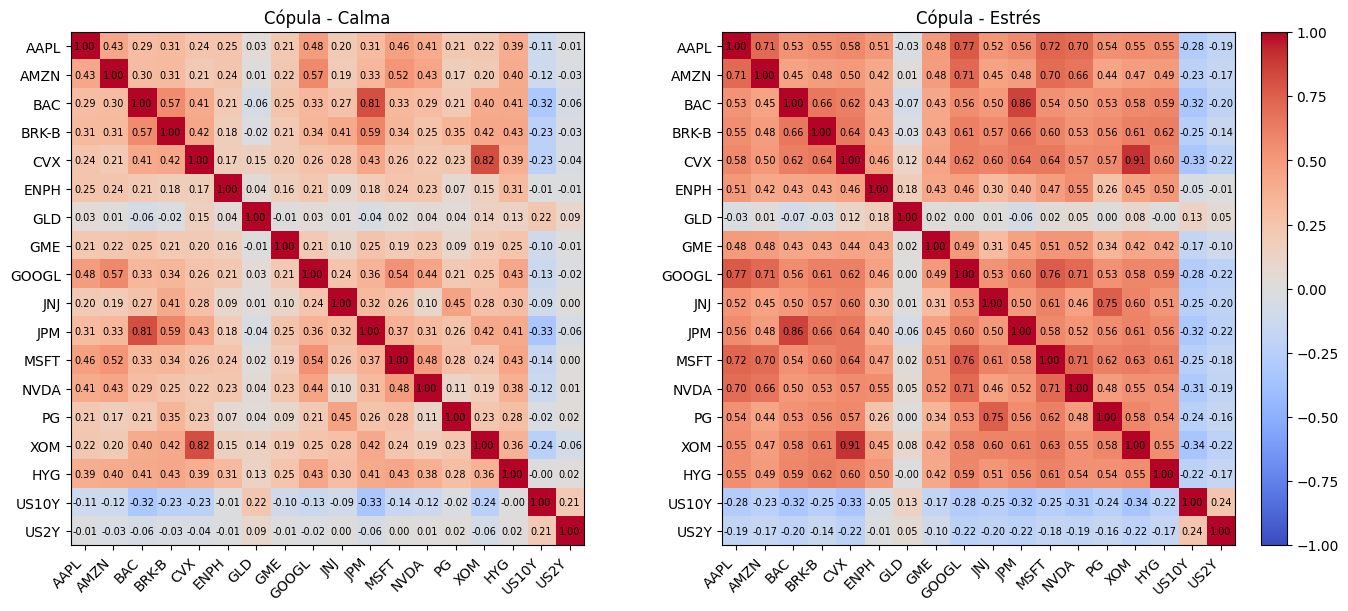

,AAPL,AMZN,BAC,BRK-B,CVX,ENPH,GLD,GME,GOOGL,JNJ,JPM,MSFT,NVDA,PG,XOM,HYG,US10Y,US2Y
AAPL,0.000,0.325,0.242,0.220,0.343,0.285,0.012,0.352,0.330,0.338,0.279,0.281,0.319,0.338,0.324,0.169,0.176,0.177
AMZN,0.325,0.000,0.160,0.180,0.292,0.212,0.002,0.357,0.213,0.292,0.193,0.215,0.292,0.312,0.294,0.107,0.115,0.138
BAC,0.242,0.160,0.000,0.077,0.169,0.261,0.027,0.266,0.229,0.212,0.034,0.213,0.223,0.280,0.140,0.138,-0.007,0.117
BRK-B,0.220,0.180,0.077,0.000,0.202,0.306,-0.014,0.310,0.286,0.159,0.096,0.285,0.288,0.223,0.183,0.171,0.021,0.078
CVX,0.343,0.292,0.169,0.202,0.000,0.333,-0.019,0.319,0.381,0.365,0.197,0.410,0.379,0.363,0.088,0.218,0.067,0.194
ENPH,0.285,0.212,0.261,0.306,0.333,0.000,0.126,0.320,0.276,0.229,0.273,0.284,0.365,0.199,0.330,0.247,0.041,0.056
GLD,0.012,0.002,0.027,-0.014,-0.019,0.126,0.000,0.021,-0.021,0.013,0.047,0.029,0.021,-0.005,-0.036,-0.096,-0.088,0.009
GME,0.352,0.357,0.266,0.310,0.319,0.320,0.021,0.000,0.388,0.267,0.321,0.402,0.377,0.308,0.299,0.259,0.127,0.079
GOOGL,0.330,0.213,0.229,0.286,0.381,0.276,-0.021,0.388,0.000,0.336,0.268,0.269,0.318,0.365,0.354,0.191,0.175,0.184
JNJ,0.338,0.292,0.212,0.159,0.365,0.229,0.013,0.267,0.336,0.000,0.182,0.393,0.411,0.373,0.354,0.218,0.166,0.117


,AAPL,AMZN,BAC,BRK-B,CVX,ENPH,GLD,GME,GOOGL,JNJ,JPM,MSFT,NVDA,PG,XOM,HYG,US10Y,US2Y
AAPL,0.0,87.4,87.7,71.3,148.3,130.7,38.3,295.8,74.5,177.9,95.1,64.9,85.6,166.9,149.8,45.3,156.1,755.7
AMZN,87.4,0.0,59.3,64.6,153.2,113.9,533.8,352.3,43.5,184.0,66.6,46.4,82.5,245.0,167.8,31.3,110.7,383.9
BAC,87.7,59.3,0.0,14.5,43.9,140.0,50.8,236.5,76.5,86.7,4.2,69.3,87.4,143.9,37.0,35.1,-2.2,216.9
BRK-B,71.3,64.6,14.5,0.0,47.6,190.5,-54.9,347.0,91.5,39.8,17.2,87.9,119.6,69.6,44.8,42.0,9.4,669.0
CVX,148.3,153.2,43.9,47.6,0.0,208.7,-13.0,336.7,162.5,134.4,48.3,167.6,195.0,174.4,10.8,57.3,30.8,990.5
ENPH,130.7,113.9,140.0,190.5,208.7,0.0,237.4,504.0,158.9,324.6,176.8,142.5,200.0,318.1,263.3,89.5,583.7,4283.4
GLD,38.3,533.8,50.8,-54.9,-13.0,237.4,0.0,2047.8,-79.5,121.6,120.3,198.4,51.8,-13.2,-26.5,-78.6,-42.6,14.1
GME,295.8,352.3,236.5,347.0,336.7,504.0,2047.8,0.0,420.4,658.6,283.7,442.6,341.4,1503.2,298.6,206.7,347.5,1130.0
GOOGL,74.5,43.5,76.5,91.5,162.5,158.9,-79.5,420.4,0.0,162.0,82.7,54.6,82.1,205.3,162.4,50.5,164.7,1133.6
JNJ,177.9,184.0,86.7,39.8,134.4,324.6,121.6,658.6,162.0,0.0,60.8,164.7,543.7,90.7,130.1,78.7,194.6,2482.0


En términos absolutos: 144 pares han aumentado correlación, 9 pares han disminuido.


In [18]:
# DEPENDENCIA MULTIACTIVO

# Cópula
def copula_corr(df):
    ranks = df.rank(pct=True).clip(1e-6, 1 - 1e-6)
    z = norm.ppf(ranks)
    return pd.DataFrame(np.corrcoef(z, rowvar=False), index=df.columns, columns=df.columns)

# Heatmap pare observar correlaciones de forma clara
def plot_corr_heatmap(ax, corr, title):
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm")

    ax.set_xticks(np.arange(len(corr.columns)))
    ax.set_yticks(np.arange(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr.index)

    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", color="black", fontsize=7)

    ax.set_title(title)
    return im

# Guardado en variables (pueden tener NaN en HYG/ENPH por fechas limitadas)
corr_calm_assets = returns_all[state_series == 0].corr()
corr_stress_assets = returns_all[state_series == 1].corr()
copula_calm = copula_corr(returns_all[state_series == 0])
copula_stress = copula_corr(returns_all[state_series == 1])

# Rellenar cada activo tardío con su propia cópula/corr desde la fecha en que tiene datos
assets_late = [c for c in ['HYG', 'ENPH'] if c in returns_all.columns]
for col in assets_late:
    for state_val, corr_assets, copula in [(0, corr_calm_assets, copula_calm), (1, corr_stress_assets, copula_stress)]:
        r_col = returns_all[state_series == state_val].dropna(subset=[col])
        if len(r_col) > 10:
            corr_full = r_col.corr()
            copula_full = copula_corr(r_col)
            corr_assets[col] = corr_full[col]
            corr_assets.loc[col] = corr_full.loc[col]
            copula[col] = copula_full[col]
            copula.loc[col] = copula_full.loc[col]

# Pearson lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
im1 = plot_corr_heatmap(axes[0], corr_calm_assets, "Pearson - Calma")
plot_corr_heatmap(axes[1], corr_stress_assets, "Pearson - Estrés")
fig.colorbar(im1, ax=axes, location="right", fraction=0.046, pad=0.02)
plt.show()

# Cópula lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
im2 = plot_corr_heatmap(axes[0], copula_calm, "Cópula - Calma")
plot_corr_heatmap(axes[1], copula_stress, "Cópula - Estrés")
fig.colorbar(im2, ax=axes, location="right", fraction=0.046, pad=0.02)
plt.show()

# % cambio de correlación por par de activos (Calma → Estrés)
delta_corr = np.abs(corr_stress_assets) - np.abs(corr_calm_assets)
np.fill_diagonal(delta_corr.values, np.nan)
pct_corr = 100 * delta_corr / (np.abs(corr_calm_assets) + 1e-8)
np.fill_diagonal(pct_corr.values, np.nan)

# TABLA 1: Cambio absoluto
html1 = '<h3>Cambio Absoluto en Correlación (|Estrés| - |Calma|)</h3>'
html1 += '<table style="border-collapse: collapse; text-align: center; background-color: white;">'
html1 += '<tr><th style="background-color: white; padding: 5px; border: 1px solid black; font-weight: bold;"></th>'
for col in delta_corr.columns:
    html1 += f'<th style="background-color: white; padding: 5px; border: 1px solid black; font-weight: bold;">{col}</th>'
html1 += '</tr>'

for idx in delta_corr.index:
    html1 += f'<tr><th style="background-color: white; padding: 5px; border: 1px solid black; font-weight: bold;">{idx}</th>'
    for col in delta_corr.columns:
        val = delta_corr.loc[idx, col]
        if pd.isna(val):
            color = 'background-color: white'
            text = ''
        elif val > 0:
            color = 'background-color: #D4EDDA'  # verde pastel suave
            text = f'{val:.3f}'
        elif val < 0:
            color = 'background-color: #F8D7DA'  # rojo pastel suave
            text = f'{val:.3f}'
        else:
            color = 'background-color: white'
            text = f'{val:.3f}'
        html1 += f'<td style="{color}; color: black; padding: 5px; border: 1px solid black;">{text}</td>'
    html1 += '</tr>'
html1 += '</table>'

# TABLA 2: Cambio porcentual
html2 = '<h3>Cambio Porcentual en Correlación (%)</h3>'
html2 += '<table style="border-collapse: collapse; text-align: center; background-color: white;">'
html2 += '<tr><th style="background-color: white; padding: 5px; border: 1px solid black; font-weight: bold;"></th>'
for col in pct_corr.columns:
    html2 += f'<th style="background-color: white; padding: 5px; border: 1px solid black; font-weight: bold;">{col}</th>'
html2 += '</tr>'

for idx in pct_corr.index:
    html2 += f'<tr><th style="background-color: white; padding: 5px; border: 1px solid black; font-weight: bold;">{idx}</th>'
    for col in pct_corr.columns:
        val = pct_corr.loc[idx, col]
        if pd.isna(val):
            color = 'background-color: white'
            text = ''
        elif val > 0:
            color = 'background-color: #D4EDDA'  # verde pastel suave
            text = f'{val:.1f}'
        elif val < 0:
            color = 'background-color: #F8D7DA'  # rojo pastel suave
            text = f'{val:.1f}'
        else:
            color = 'background-color: white'
            text = f'{val:.1f}'
        html2 += f'<td style="{color}; color: black; padding: 5px; border: 1px solid black;">{text}</td>'
    html2 += '</tr>'
html2 += '</table>'

from IPython.display import HTML
display(HTML(html1))
display(HTML(html2))

n_up = int((delta_corr > 0).sum().sum() // 2)
n_down = int((delta_corr < 0).sum().sum() // 2)

print(f"En términos absolutos: {n_up} pares han aumentado correlación, {n_down} pares han disminuido.")


> **Nota sobre la metodología**
>
> Se calculan las cópulas de todos los activos desde su fecha de primera disponibilidad.
Si bien esto puede generar cierto sesgo al no contar con datos previos, consideramos que es la metodología que permite maximizar la información disponible para el análisis.
>
> Por lo tanto, para todos los activos, salvo HYG y ENPH, se calculan los datos desde el 2026-01-01. Los datos de HYG se incorporan a la matriz desde su primera fecha de disponibilidad, y los de ENPH desde su respectiva fecha de incorporación.
>
> La alternativa —completar el análisis utilizando algún tipo de proxy o activo comparable para los periodos no disponibles— nos parecía demasiado artificial y metodológicamente cuestionable.

### <font color=#336699>**2.5. Motor de simulación (Monte Carlo con regímenes)**</font>

El simulador sigue estos pasos por día:
1) Simular estado con la cadena de Markov (HMM),
2) Simular retornos condicionados al estado usando marginales + cópula.

Se usa una transformación ECDF por activo y estado para mantener la forma empírica de las distribuciones.

In [19]:
# MOTOR DE SIMULACIÓN
# Parámetros básicos
rng = np.random.default_rng(42)
assets = returns_all.columns.tolist()

returns_by_state = {
    0: returns_all[state_series == 0],
    1: returns_all[state_series == 1]
}

state_means = {s: returns_by_state[s].mean().values for s in returns_by_state}
state_stds = {s: returns_by_state[s].std().values for s in returns_by_state}

# Inversa ECDF para cada activo/estado
inv_cdf = {}
for s, df in returns_by_state.items():
    inv_cdf[s] = []
    for col in df.columns:
        vals = np.sort(df[col].dropna().values)
        p = np.linspace(0, 1, len(vals), endpoint=True)
        inv_cdf[s].append((p, vals))

# Funciones de muestreo de cópula

def sample_gaussian_copula(n, corr):
    z = rng.multivariate_normal(mean=np.zeros(corr.shape[0]), cov=corr, size=n)
    u = norm.cdf(z)
    return u


def sample_t_copula(n, corr, df):
    from scipy.stats import t as t_dist
    z = rng.multivariate_normal(mean=np.zeros(corr.shape[0]), cov=corr, size=n)
    g = rng.chisquare(df, size=n)
    t = z / np.sqrt(g / df)[:, None]
    u = t_dist.cdf(t, df)
    return u


def simulate_states(n_paths, n_steps, transmat, start_prob):
    n_states = transmat.shape[0]
    states = np.empty((n_paths, n_steps), dtype=np.int8)
    states[:, 0] = rng.choice(n_states, size=n_paths, p=start_prob)

    for t in range(1, n_steps):
        prev = states[:, t - 1]
        for s in range(n_states):
            idx = np.where(prev == s)[0]
            if idx.size == 0:
                continue
            states[idx, t] = rng.choice(n_states, size=idx.size, p=transmat[s])
    return states


def map_uniforms_to_returns(u, inv_cdf_state, mean, std, mean_shift=None, vol_mult=None):
    mapped = np.empty_like(u)
    for j in range(u.shape[1]):
        p, vals = inv_cdf_state[j]
        mapped[:, j] = np.interp(u[:, j], p, vals)

    if mean_shift is None:
        mean_shift = np.zeros(u.shape[1])
    if vol_mult is None:
        vol_mult = np.ones(u.shape[1])

    # Ajuste lineal de media/vol para escenarios
    mapped = mean + mean_shift + vol_mult * (mapped - mean)
    return mapped


def simulate_returns(n_paths, n_steps, transmat, start_prob, copula_calm, copula_stress, df_stress=4,
                     mean_shift=None, vol_mult=None):
    states = simulate_states(n_paths, n_steps, transmat, start_prob)
    sim = np.empty((n_paths, n_steps, len(assets)), dtype=np.float32)

    for t in range(n_steps):
        for s in [0, 1]:
            idx = np.where(states[:, t] == s)[0]
            if idx.size == 0:
                continue

            if s == 0:
                u = sample_gaussian_copula(idx.size, copula_calm)
            else:
                u = sample_t_copula(idx.size, copula_stress, df=df_stress)

            sim[idx, t, :] = map_uniforms_to_returns(
                u,
                inv_cdf[s],
                mean=state_means[s],
                std=state_stds[s],
                mean_shift=None if mean_shift is None else mean_shift.get(s),
                vol_mult=None if vol_mult is None else vol_mult.get(s)
            )

    return sim, states

#### 2.5.1. Simulación base (10.000 trayectorias, 6 meses)

Se genera el abanico base que luego se compara con datos reales y escenarios.

In [20]:
# SIMULACIÓN BASE
transmat = transmat_emp
start_prob = start_prob_emp

sim_returns, sim_states = simulate_returns(
    n_paths=n_paths,
    n_steps=horizon_days,
    transmat=transmat,
    start_prob=start_prob,
    copula_calm=copula_calm.values,
    copula_stress=copula_stress.values,
    df_stress=4
)

portfolio_sim = sim_returns.mean(axis=2)
wealth_sim = np.cumprod(1 + portfolio_sim, axis=1)

print(f"Simulación completada: {sim_returns.shape} (paths, days, assets)")

Simulación completada: (10000, 126, 18) (paths, days, assets)


### <font color=#336699>**2.6. Validación del simulador**</font>

Se validan cartera, regímenes y métricas de riesgo (real vs simulado) para comprobar que el simulador reproduce el comportamiento histórico antes de estresar escenarios.

#### 2.6.1. Test de cartera (sanity check)

Se compara gráficamente la evolución histórica real de la cartera con las bandas p5-p50-p95 del wealth simulado. También se grafica la distribución de retornos diarios simulados vs. reales (histograma).

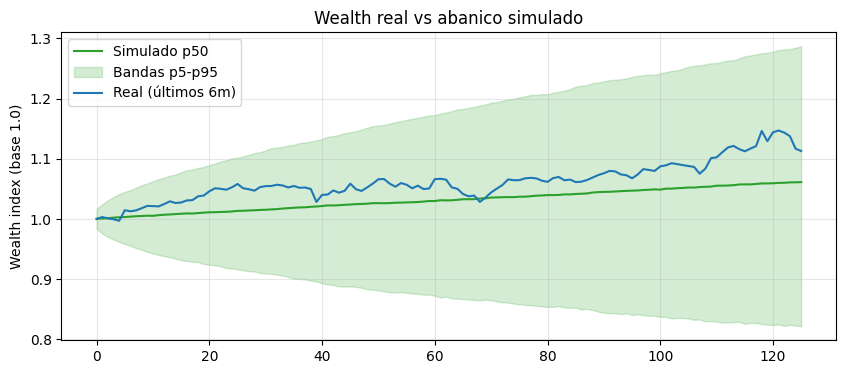

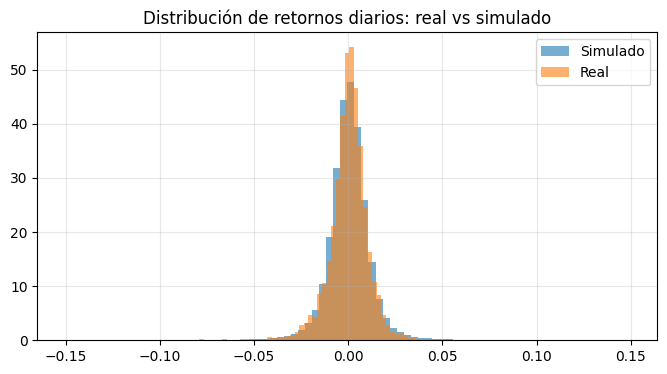

In [21]:
# Sanity check de cartera
p5 = np.percentile(wealth_sim, 5, axis=0)
p50 = np.percentile(wealth_sim, 50, axis=0)
p95 = np.percentile(wealth_sim, 95, axis=0)

plt.figure(figsize=(10, 4))
plt.plot(range(horizon_days), p50, label="Simulado p50", color="#2ca02c")
plt.fill_between(range(horizon_days), p5, p95, color="#2ca02c", alpha=0.2, label="Bandas p5-p95")

# Para comparar, reescalamos la serie real a 6 meses desde un punto reciente
real_window = wealth_real.iloc[-horizon_days:]
real_window = real_window / real_window.iloc[0]
plt.plot(range(horizon_days), real_window.values, color="#1f77b4", label="Real (últimos 6m)")

plt.title("Wealth real vs abanico simulado")
plt.ylabel("Wealth index (base 1.0)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Distribución de retornos diarios (real vs simulado)
plt.figure(figsize=(8, 4))
plt.hist(portfolio_sim.flatten(), bins=80, alpha=0.6, density=True, label="Simulado")
plt.hist(portfolio_returns.values, bins=80, alpha=0.6, density=True, label="Real")
plt.title("Distribución de retornos diarios: real vs simulado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### 2.6.2. Reproducción de regímenes

Se comparan las siguientes métricas (real vs. simulado):
- <u>% de días en cada estado</u>
- <u>Duración media de cada estado</u>
- <u>Número de cambios de estado</u>

In [22]:
# REPRODUCCIÓN DE REGÍMENES
def regime_stats_series(states_1d):
    states_1d = np.asarray(states_1d)
    pct = {s: np.mean(states_1d == s) for s in [0, 1]}

    # Duraciones medias
    durations = {0: [], 1: []}
    current = states_1d[0]
    run = 1
    for x in states_1d[1:]:
        if x == current:
            run += 1
        else:
            durations[current].append(run)
            current = x
            run = 1
    durations[current].append(run)

    avg_dur = {s: (np.mean(durations[s]) if durations[s] else 0) for s in [0, 1]}
    switches = np.sum(states_1d[1:] != states_1d[:-1])

    return pct, avg_dur, switches

# Real
pct_real, dur_real, sw_real = regime_stats_series(state_series.values)

# Simulado (promedio entre trayectorias)
all_pct = {0: [], 1: []}
all_dur = {0: [], 1: []}
all_sw = []

for i in range(sim_states.shape[0]):
    pct, dur, sw = regime_stats_series(sim_states[i])
    all_pct[0].append(pct[0])
    all_pct[1].append(pct[1])
    all_dur[0].append(dur[0])
    all_dur[1].append(dur[1])
    all_sw.append(sw)

summary = pd.DataFrame({
    "Real": [pct_real[0], pct_real[1], dur_real[0], dur_real[1], sw_real],
    "Simulado (media)": [
        np.mean(all_pct[0]), np.mean(all_pct[1]),
        np.mean(all_dur[0]), np.mean(all_dur[1]),
        np.mean(all_sw)
    ]
}, index=["% días Calma", "% días Crisis", "Duración media Calma", "Duración media Crisis", "Nº cambios estado"])

summary

,Real,Simulado (media)
% días Calma,0.874555,0.874029
% días Crisis,0.125445,0.125971
Duración media Calma,294.666667,99.877292
Duración media Crisis,45.285714,14.537350
Nº cambios estado,28.000000,0.681800


> <u>Comentario</u>: La distribución de días de Calma y Crisis es terriblemente precisa, mientras las duraciones medias de Calma y Crisis son más cortas (en este caso, por la estrechez de las simulaciones a solo 6 meses). Esto se verá también reflejado en un menor Max Drawdown, de nuevo no derivado de una mala adecuación de los datos si no a unas simulaciones más cortas.
>
> Sería interesante analizar, sobre periodos más largos, la adecuación de la matriz de transición para identificar periodos de crisis y calma más largos y analizar los MaxDD correspondientes, para acabar de validar nuestra modelización de los datos.

#### 2.6.3. Reproducción de riesgo y dependencia

Se compara para la cartera equiponderada (real vs. simulado):
- <u>Volatilidad (diaria/anualizada)</u>
- <u>Máximo Drawdown</u>
- <u>Var 99% y Expected Shortfall (CVar 99%)N</u>

In [23]:
# REPRODUCCIÓN DE RIESGO Y DEPENDENCIA
def var_es(returns, alpha=0.99):
    var = np.quantile(returns, 1 - alpha)
    es = returns[returns <= var].mean()
    return var, es


def max_drawdown(wealth_series):
    peak = np.maximum.accumulate(wealth_series)
    drawdown = wealth_series / peak - 1.0
    return drawdown.min()

# Real metrics
real_vol = portfolio_returns.std() * np.sqrt(252)
real_mdd = max_drawdown(wealth_real.values)
real_var, real_es = var_es(portfolio_returns.values, alpha=0.99)

# Simulated metrics (usamos distribución diaria simulada)
sim_vol = portfolio_sim.flatten().std() * np.sqrt(252)
# MDD medio en simulaciones
sim_mdd = np.mean([max_drawdown(w) for w in wealth_sim])
sim_var, sim_es = var_es(portfolio_sim.flatten(), alpha=0.99)

metrics = pd.DataFrame({
    "Real": [real_vol, real_mdd, real_var, real_es],
    "Simulado": [sim_vol, sim_mdd, sim_var, sim_es]
}, index=["Vol anualizada", "Max drawdown", "VaR 99% (diario)", "ES 99% (diario)"])

print('Métricas (real vs. simulado):')
display(metrics)

# Volatilidades por estado (real y simulado)
sim_df = pd.DataFrame(sim_returns.reshape(-1, len(assets)), columns=assets)
sim_states_flat = sim_states.reshape(-1)

vol_real_calm = portfolio_returns[state_series == 0].std() * np.sqrt(252)
vol_real_stress = portfolio_returns[state_series == 1].std() * np.sqrt(252)
port_sim_flat = portfolio_sim.reshape(-1)
vol_sim_calm = port_sim_flat[sim_states_flat == 0].std() * np.sqrt(252)
vol_sim_stress = port_sim_flat[sim_states_flat == 1].std() * np.sqrt(252)

vol_by_state = pd.DataFrame({
    "Real": [vol_real_calm, vol_real_stress],
    "Simulado": [vol_sim_calm, vol_sim_stress]
}, index=["Calma", "Estrés"])
print("\nVolatilidad anualizada por estado (cartera equiponderada):")
display(vol_by_state)

# Correlaciones por estado (real y simulado)
corr_sim_calm = sim_df[sim_states_flat == 0].corr().values
corr_sim_stress = sim_df[sim_states_flat == 1].corr().values
avg_corr_calm = (corr_sim_calm[np.triu_indices_from(corr_sim_calm, 1)]).mean()
avg_corr_stress = (corr_sim_stress[np.triu_indices_from(corr_sim_stress, 1)]).mean()
corr_real_calm = returns_all[state_series == 0].corr().values
corr_real_stress = returns_all[state_series == 1].corr().values
avg_corr_real_calm = (corr_real_calm[np.triu_indices_from(corr_real_calm, 1)]).mean()
avg_corr_real_stress = (corr_real_stress[np.triu_indices_from(corr_real_stress, 1)]).mean()
print(f"\nCorrelación media fuera de diagonal (real): Calma={avg_corr_real_calm:.2f}, Estrés={avg_corr_real_stress:.2f}")
print(f"Correlación media fuera de diagonal (simulado): Calma={avg_corr_calm:.2f}, Estrés={avg_corr_stress:.2f}")



Métricas (real vs. simulado):


,Real,Simulado
Vol anualizada,0.179348,0.185277
Max drawdown,-0.522375,-0.115077
VaR 99% (diario),-0.031544,-0.032728
ES 99% (diario),-0.046463,-0.047469



Volatilidad anualizada por estado (cartera equiponderada):


,Real,Simulado
Calma,0.133578,0.140872
Estrés,0.363013,0.366536



Correlación media fuera de diagonal (real): Calma=0.18, Estrés=0.34
Correlación media fuera de diagonal (simulado): Calma=0.19, Estrés=0.34


> <u>Comentario</u>: Se puede observar cómo en escenarios de estrés el simulador reproduce un aumento de volatilidades y cambios en correlaciones coherentes con crisis.

### <font color=#336699>**2.7. Escenarios de estrés (6 meses, 10.000 simulaciones)**</font>

Definimos tres escenarios y justificamos su lógica económica. Cada escenario ajusta probabilidades de régimen, medias/volatilidades y dependencia:
- <u>Estanflación 2022</u>: presión en equities y crédito, tipos al alza; oil y oro con sesgo defensivo.
- <u>Crisis de crédito 2008</u>: shocks generalizados y cola más pesada, con refugio parcial en bonos y oro.
- <u>Tensión de liquidez (alternativo)</u>: ampliación de spreads y venta forzada en activos de riesgo.

**Justificación económica de la implementación:**

- **Estanflación 2022.** En el código se impone un sesgo negativo en renta variable y en HYG (high yield) y se eleva la volatilidad de estos activos, coherente con la subida de tipos y el endurecimiento financiero de 2022. El oro (GLD) recibe un sesgo positivo y mayor vol como activo refugio e inflación; el petróleo (CVX, XOM) se deja ligeramente positivo por la tensión energética del periodo. Los bonos (US10Y, US2Y) tienen retorno medio negativo y vol elevada, reflejando las pérdidas por repricing ante subidas de tipos. Se mantiene la matriz de transición empírica y una cópula t con 4 grados de libertad, asumiendo que el régimen de estrés no es tan persistente ni extremo como en una crisis sistémica.

- **Crisis de Crédito 2008.** Se modela un shock sistémico: todos los activos con sesgo negativo fuerte y volatilidad multiplicada (cola más pesada). El oro recibe un sesgo positivo y vol moderada como refugio; los bonos (US10Y, US2Y) tienen sesgo positivo y menor castigo, replicando la huida a calidad y la caída de tipos en la crisis. La matriz de transición se fuerza a mayor persistencia en estrés (alta probabilidad de permanecer en crisis) y mayor probabilidad de paso de calma a estrés; la probabilidad inicial se fija en [0.2, 0.8] para arrancar mayoritariamente en régimen de crisis. La cópula t con 3 grados de libertad refuerza las colas y los co-movimientos extremos típicos de 2008.

- **Tensión de liquidez (alternativo).** Escenario de venta forzada y ampliación de spreads: todos los activos con sesgo negativo y volatilidad elevada (multiplicador 1.8), sin refugio claro salvo un ligero sesgo positivo en oro. No se asume colapso de tipos como en 2008, sino estrés de liquidez y correlaciones altas en la bajada. La matriz de transición se modera respecto a 2008 (más persistencia en estrés que la empírica, pero menos extrema), manteniendo la cópula t con 4 grados de libertad. Así se "rompe" la cartera con un escenario distinto al de estanflación (sin refugio en commodities/bonos) y al de crisis de crédito (menor persistencia y colas algo menos gruesas).

In [24]:
# ESCENARIOS DE ESTRÉS

asset_index = {a: i for i, a in enumerate(assets)}


def build_shift_and_vol(base_shift=0.0, base_vol=1.0):
    shift = np.full(len(assets), base_shift)
    vol = np.full(len(assets), base_vol)
    return shift, vol


def scenario_params(name):
    # Valores diarios aproximados para forzar escenarios coherentes
    if name == "Estanflación 2022":
        shift, vol = build_shift_and_vol(0.0, 1.2)
        # Acciones y HYG bajo presión
        for a in ["AAPL", "AMZN", "BAC", "BRK-B", "CVX", "ENPH", "GME", "GOOGL", "JNJ", "JPM", "MSFT", "NVDA", "PG", "XOM", "HYG"]:
            shift[asset_index[a]] = -0.0005
            vol[asset_index[a]] = 1.6
        # Oil positivo, oro defensivo
        shift[asset_index["GLD"]] = 0.0002
        vol[asset_index["GLD"]] = 1.3
        shift[asset_index["CVX"]] = 0.0001
        shift[asset_index["XOM"]] = 0.0001
        # Bonos sufren por subida de tipos
        shift[asset_index["US10Y"]] = -0.0002
        shift[asset_index["US2Y"]] = -0.00015
        vol[asset_index["US10Y"]] = 1.4
        vol[asset_index["US2Y"]] = 1.3

        trans = transmat_emp
        start = start_prob_emp
        df_stress = 4

    elif name == "Crisis de Crédito 2008":
        shift, vol = build_shift_and_vol(0.0, 1.0)
        for a in assets:
            shift[asset_index[a]] = -0.0007
            vol[asset_index[a]] = 2.0
        # Oro algo mejor, bonos algo defensivos
        shift[asset_index["GLD"]] = 0.0003
        vol[asset_index["GLD"]] = 1.5
        shift[asset_index["US10Y"]] = 0.0002
        shift[asset_index["US2Y"]] = 0.0001

        trans = transmat_emp.copy()
        trans[0, 1] = 0.06
        trans[0, 0] = 0.94
        trans[1, 1] = 0.97
        trans[1, 0] = 0.03
        start = np.array([0.2, 0.8])
        df_stress = 3

    else:  # Escenario alternativo: tensión de liquidez
        shift, vol = build_shift_and_vol(0.0, 1.5)
        for a in assets:
            shift[asset_index[a]] = -0.0004
            vol[asset_index[a]] = 1.8
        # Oro ligeramente positivo
        shift[asset_index["GLD"]] = 0.0001
        vol[asset_index["GLD"]] = 1.4

        trans = transmat_emp.copy()
        trans[0, 1] = 0.04
        trans[0, 0] = 0.96
        trans[1, 1] = 0.95
        trans[1, 0] = 0.05
        start = start_prob_emp
        df_stress = 4

    mean_shift = {0: shift, 1: shift}
    vol_mult = {0: vol, 1: vol}
    return mean_shift, vol_mult, trans, start, df_stress


def scenario_run(name):
    mean_shift, vol_mult, trans, start, df_stress = scenario_params(name)
    sim_ret, sim_st = simulate_returns(
        n_paths=n_paths,
        n_steps=horizon_days,
        transmat=trans,
        start_prob=start,
        copula_calm=copula_calm.values,
        copula_stress=copula_stress.values,
        df_stress=df_stress,
        mean_shift=mean_shift,
        vol_mult=vol_mult
    )

    portfolio_sim_s = sim_ret.mean(axis=2)
    wealth_sim_s = np.cumprod(1 + portfolio_sim_s, axis=1)
    cum_returns = wealth_sim_s[:, -1] - 1

    var_99 = np.quantile(cum_returns, 0.01)
    es_99 = cum_returns[cum_returns <= var_99].mean()

    return var_99, es_99

scenarios = ["Estanflación 2022", "Crisis de Crédito 2008", "Tensión de liquidez (alternativo)"]

scenario_results = []
for s in scenarios:
    var_99, es_99 = scenario_run(s)
    scenario_results.append([s, var_99, es_99])

scenario_df = pd.DataFrame(scenario_results, columns=["Escenario", "VaR 99% (6m)", "ES 99% (6m)"])
scenario_df

,Escenario,VaR 99% (6m),ES 99% (6m)
0,Estanflación 2022,-0.475413,-0.546880
1,Crisis de Crédito 2008,-0.723436,-0.758214
2,Tensión de liquidez (alternativo),-0.623938,-0.662804


#### 2.7.1. Validación de escenarios (comparación con base)

Comparación base vs estrés con bandas percentiles y distribuciones de retornos.

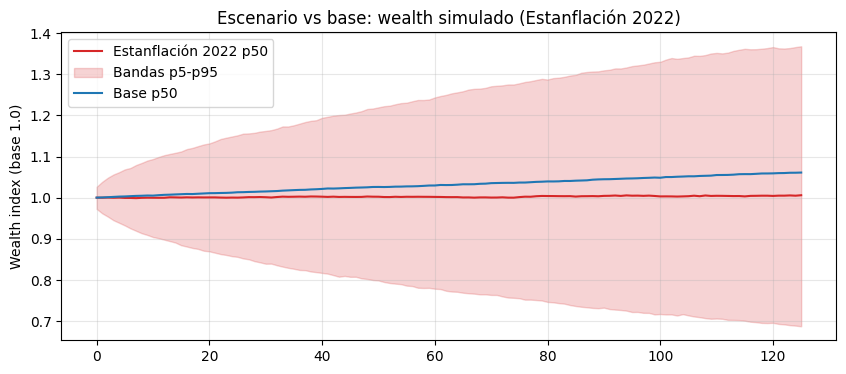

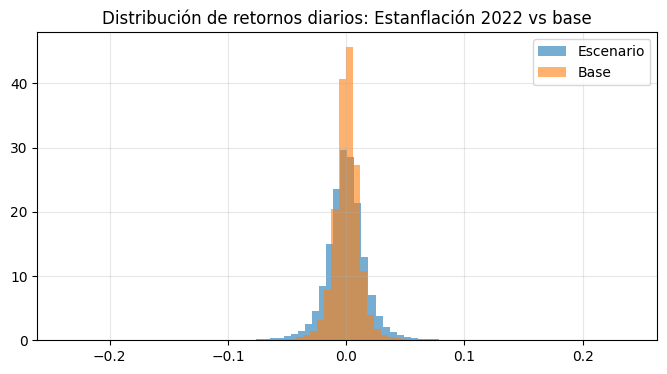

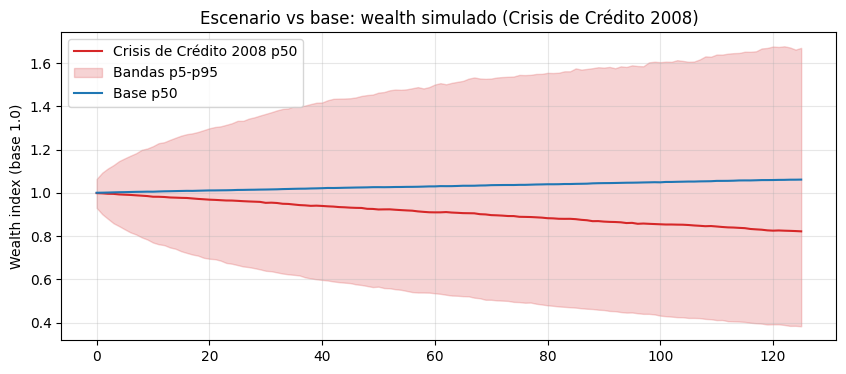

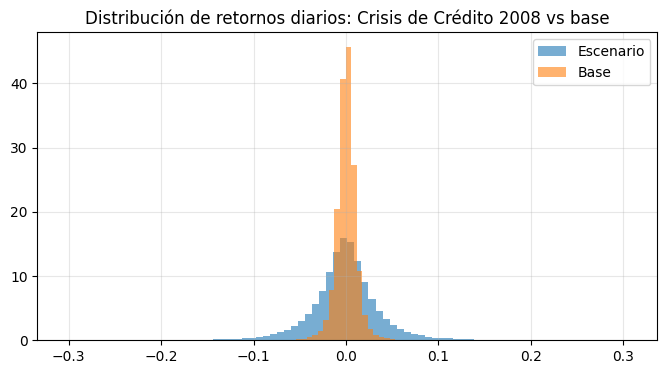

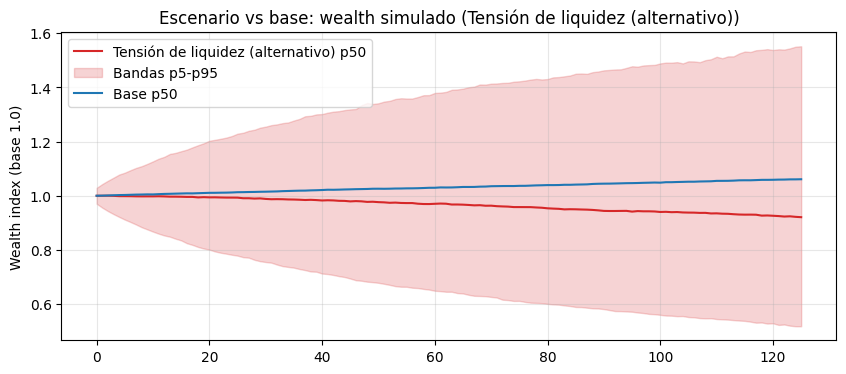

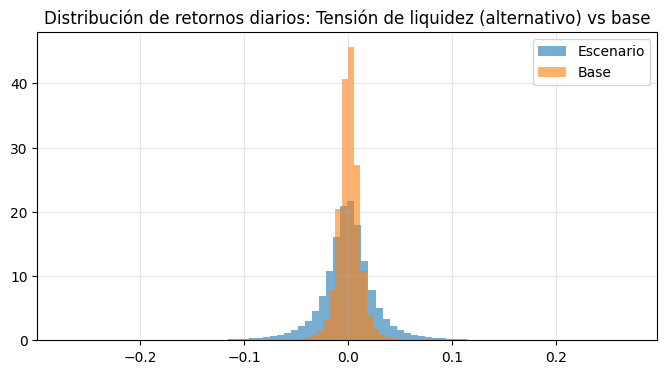

In [25]:
def scenario_simulate_full(name):
    mean_shift, vol_mult, trans, start, df_stress = scenario_params(name)
    sim_ret, _ = simulate_returns(
        n_paths=n_paths,
        n_steps=horizon_days,
        transmat=trans,
        start_prob=start,
        copula_calm=copula_calm.values,
        copula_stress=copula_stress.values,
        df_stress=df_stress,
        mean_shift=mean_shift,
        vol_mult=vol_mult
    )
    portfolio_sim_s = sim_ret.mean(axis=2)
    wealth_sim_s = np.cumprod(1 + portfolio_sim_s, axis=1)
    cum_returns = wealth_sim_s[:, -1] - 1
    var_99 = np.quantile(cum_returns, 0.01)
    es_99 = cum_returns[cum_returns <= var_99].mean()
    return {
        "portfolio_sim": portfolio_sim_s,
        "wealth_sim": wealth_sim_s,
        "var_99": var_99,
        "es_99": es_99
    }

# Base (sin escenario)
base_cum = wealth_sim[:, -1] - 1
base_var_99 = np.quantile(base_cum, 0.01)
base_es_99 = base_cum[base_cum <= base_var_99].mean()

scenario_sims = {s: scenario_simulate_full(s) for s in scenarios}

# Tabla comparativa base vs escenarios
compare_rows = [["Base", base_var_99, base_es_99]]
for s in scenarios:
    compare_rows.append([s, scenario_sims[s]["var_99"], scenario_sims[s]["es_99"]])

compare_df = pd.DataFrame(compare_rows, columns=["Escenario", "VaR 99% (6m)", "ES 99% (6m)"])
compare_df

# Validación visual: bandas p5-p50-p95 vs base
base_p50 = np.percentile(wealth_sim, 50, axis=0)

for s in scenarios:
    w = scenario_sims[s]["wealth_sim"]
    p5 = np.percentile(w, 5, axis=0)
    p50 = np.percentile(w, 50, axis=0)
    p95 = np.percentile(w, 95, axis=0)

    plt.figure(figsize=(10, 4))
    plt.plot(range(horizon_days), p50, label=f"{s} p50", color="#d62728")
    plt.fill_between(range(horizon_days), p5, p95, color="#d62728", alpha=0.2, label="Bandas p5-p95")
    plt.plot(range(horizon_days), base_p50, color="#1f77b4", label="Base p50")
    plt.title(f"Escenario vs base: wealth simulado ({s})")
    plt.ylabel("Wealth index (base 1.0)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Distribución diaria: escenario vs base
    plt.figure(figsize=(8, 4))
    plt.hist(scenario_sims[s]["portfolio_sim"].flatten(), bins=80, alpha=0.6, density=True, label="Escenario")
    plt.hist(portfolio_sim.flatten(), bins=50, alpha=0.6, density=True, label="Base")
    plt.title(f"Distribución de retornos diarios: {s} vs base")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

> <u>Comentario</u>: En los tres escenarios la mediana del wealth (p50) queda por debajo de la base y las bandas p5–p95 se ensanchan, lo que refleja mayor incertidumbre y riesgo de cola. Las distribuciones de retornos diarios (histogramas) muestran colas más anchas y menor concentración en torno a cero que en la base, coherente con un entorno de estrés. En conjunto, los gráficos validan que el motor de stress testing penaliza correctamente tanto el nivel esperado de wealth como la dispersión de resultados.

### <font color=#336699>**2.8. Conclusión Sección II**</font>

En esta sección se ha construido un motor de simulación de wealth para la cartera multiactivo, condicionado a los regímenes HMM y a escenarios de estrés históricos. El motor reproduce patrones reales de riesgo (volatilidad, drawdown, VaR/ES y correlaciones) y genera trayectorias coherentes con esos regímenes. Bajo escenarios de estrés, las pérdidas extremas (VaR/ES) aumentan de forma significativa frente al escenario base, indicando que la cartera se “rompe” cuando la dependencia en colas y la volatilidad se intensifican. En conjunto, la Sección II aporta una base cuantitativa para evaluar capital económico o límites de pérdida en condiciones adversas.


## <font color=#0099CC>**3. CONCLUSIÓN**</font>

En esta práctica se ha construido un motor de stress testing interpretable que captura cambios de régimen de mercado y riesgo de cola, en línea con el mandato del Comité: modelos clásicos y explicables (HMM, cópulas, Monte Carlo), sin cajas negras ni Deep Learning.

- <u>Sección I</u>: Permitió identificar el “pulso” del mercado mediante un Gaussian HMM de dos estados (calma y crisis) sobre variables representativas del ciclo (S&P 500, VIX, curva de tipos 2Y/10Y, DXY, oro y petróleo). El modelo distingue de forma cuantitativa y visual ambos regímenes, con diferencias claras en volatilidad, asimetrías y co-movimientos. El análisis marginal por estado responde a las preguntas del enunciado: la volatilidad del High Yield (HYG) aumenta de calma a crisis, y el oro (GLD) se comporta más como descorrelacionador que como refugio sistemático. Las cópulas ajustadas por estado (incluyendo dependencia en colas en estrés) y la comparación de correlaciones entre regímenes muestran que en crisis la diversificación falla y las correlaciones se elevan, coherente con la experiencia de 2008 y 2022.

- <u>Sección II</u>: Se implementó el motor de simulación; 10.000 trayectorias a 6 meses, con estado simulado por la cadena de Markov del HMM y retornos multiactivo condicionados a marginales y cópula por régimen. La validación obligatoria se cumplió: (A) test de cartera con bandas p5–p50–p95 de wealth y distribución de retornos diarios real vs simulado; (B) reproducción de regímenes (% días por estado, duración media, cambios de estado); (C) reproducción de volatilidad, drawdown, VaR 99% y Expected Shortfall (CVaR 99%). Los tres escenarios de estrés —Estanflación 2022, Crisis de Crédito 2008 y Tensión de liquidez (alternativo)— se diseñaron para “romper la cartera” con supuestos económicamente coherentes; en todos ellos el VaR 99% y el ES 99% aumentan de forma significativa frente al escenario base, y la comparación visual (wealth y distribuciones diarias) confirma que el motor penaliza correctamente nivel y dispersión en condiciones adversas.

En conjunto, el notebook entrega un motor de stress testing listo para cuantificar pérdidas extremas y apoyar decisiones de capital económico o límites de pérdida, con total interpretabilidad y alineado con las reglas y restricciones de la práctica.